<a href="https://colab.research.google.com/github/pinkadace-code/fita-ml-course/blob/main/final-project/notebooks/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

rezultati = pd.DataFrame([
    {
        "Nedēļa": "W1",
        "ML uzdevums": "Klasifikācija",
        "Labākais modelis": "Decision Tree",
        "Galvenā metrika": "F1 Score",
        "Vērtība": "0.645"
    },
    {
        "Nedēļa": "W2",
        "ML uzdevums": "Regresija",
        "Labākais modelis": "Lineārā regresija",
        "Galvenā metrika": "R²",
        "Vērtība": "0.046"  # noapaļots
    },
    {
        "Nedēļa": "W3",
        "ML uzdevums": "Klasterizācija",
        "Labākais modelis": "K-Means (K=4)",
        "Galvenā metrika": "Inertia",
        "Vērtība": "35292"
    },
    {
        "Nedēļa": "W3",
        "ML uzdevums": "Validācija (RF)",
        "Labākais modelis": "RandomForest",
        "Galvenā metrika": "CV F1 ± std",
        "Vērtība": "0.633 ± 0.043"
    }
])

print(rezultati.to_string(index=False))

Nedēļa     ML uzdevums  Labākais modelis Galvenā metrika       Vērtība
    W1   Klasifikācija     Decision Tree        F1 Score         0.645
    W2       Regresija Lineārā regresija              R²         0.046
    W3  Klasterizācija     K-Means (K=4)         Inertia         35292
    W3 Validācija (RF)      RandomForest     CV F1 ± std 0.633 ± 0.043


- Kas bija visvieglāk no trīs ML tipiem.

Visvieglākā bija klasifikācija, jo tā bija vienkāršākā - viegli saprotama un uztverama, tomēr interesantākā šķita klasterizācija, jo bija interesanti skatīties vizualizācijas un censties to izprast.
- Kas bija visgrūtāk?

Grūtākais un galvenā problēma - šo mācos tikai intereses pēc, bez saistības ar nepieciešamību darbā, arī biznesa domāšana man ir sveša. Līdz ar to grūtākais bija saprast kas, kādēļ tiek darīts, un kāda tam visam nozīme :)
- Ko tu mācītos citādi, ja sāktu no sākuma?

Es neko nedarītu citādi - lai šo mācītos, bija interesanti iet visiem uzdevumiem cauri soli pa solim kopā ar Claude un iegūt atbildes uz neskaitāmiem jautājumiem.
- Kura metrika (F1, R², Elbow, u.c.) bija visintuitīvākā un kāpēc?

Nezinu par visintuitīvāko, bet man interesanta šķita Elbow metrika, jo pirmkārt, tā ir it kā vienkārša vizuāli, bet arī tad, ja vizuāli nav viegli ieraudzīt "lūzuma punktu" vai "elkoni", krituma palēlināšanos var aprēķināt, apskatot krituma tempu starp k vērtībām.
- Kā data leakage un overfitting ietekmēja tavus rezultātus (vai nebija problēmu)?

Īsti rezultāti ietekmēti netika. Polinomiālajai regresijai nedaudz bija nosliece uz overfitting, lai gan skaitliski starpība starp treniņa un testa datiem bija uz robežas - gandrīz sasniedza 0,10 slieksni. Savukārt data leakage uzdevumos tika novērsta ar Pipeline + Cross-validation.


Kad lietot Klasifikāciju - tā ir piemērota, kad atbilde ir kategorija — "jā vai nē", "A vai B".
Piemēram, kultūras iestāde varētu lietot klasifikāciju, lai prognozētu,
vai apmeklētājs iegādāsies abonementu vai nē, balstoties uz viņa iepriekšējo
apmeklējumu vēsturi un demogrāfiskajiem datiem.

Kad lietot Regresiju - tā ir piemērota, kad atbilde ir skaitlis — cena, daudzums, ilgums.
Piemēram, mākslas izsoļu nams varētu lietot regresiju, lai prognozētu
mākslas darba pārdošanas cenu, balstoties uz autoru, izmēru, materiālu un
iepriekšējo izsolu rezultātiem.

Kad lietot Klasterizāciju - tā ir piemērota, kad iepriekš nav zināmas kategorijas un būtu nepieciešams atrast dabiskas grupas datos. Piemēram, muzejs varētu lietot
klasterizāciju, lai sagrupētu apmeklētājus pēc uzvedības un interesēm —
un katrai grupai sūtīt atšķirīgus pasākumu ieteikumus.

Pipeline un Cross-validation ir nepieciešami jebkurā no šiem gadījumiem,
jo Pipeline nodrošina, ka datu apstrāde notiek vienādā secībā gan trenēšanas,
gan testēšanas datos, novēršot data leakage. Cross-validation savukārt dod
ticamāku priekšstatu par modeļa veiktspēju, nekā vienkāršs train/test sadalījums,
jo modelis tiek pārbaudīts uz vairākos datu sadalījumos.

Ieteicamais modelis DataShop datiem

Balstoties uz pārbaudes darbu rezultātiem, es ieteiktu **Random Forest** kā modeli, kuru lietot ikdienā.

Lai gan Decision Tree uzrādīja nedaudz augstāku F1 (0.645), tas tika mērīts
vienu reizi uz viena test seta, kas var būt veiksme. Random Forest tika
pārbaudīts ar 5-fold cross-validation un uzrādīja stabilu rezultātu
(CV F1 = 0.633 ± 0.043) — tas nozīmē, ka modelis uzvedas paredzami
uz dažādām datu daļām. W2 lineārā regresija nav piemērota (R² = 0.046),
kas liecina, ka tā uz šiem datiem nestrādā pietiekami labi.

## Gala projekta plāns

**1. Dataset:**
- TMDb Top 10,000 Popular Movies Dataset (Kaggle, balaka18)
- 10 000 rindas × 7 kolonnas
- Populāru filmu datu kopa no The Movie Database, kas satur
  informāciju par vērtējumiem, popularitāti, valodu un balsu skaitu.

**2. ML problēma:**
- Vai filma tiks augsti novērtēta? Prognozēšu, vai filmas
  `vote_average` pārsniedz 7.0 (binārā klasifikācija: 1 = jā, 0 = nē).
- Šī problēma varētu būt nozīmīga filmu producētājiem un platformām,
  kas vēlas saprast, kādi faktori (popularitāte, valoda, balsu skaits)
  ietekmē skatītāju vērtējumu.

**3. ML tipu izvēle:**
- Klasifikācija (Target = `high_rating`: 1 vai 0)
- Vērtējums ir kategoriska atbilde (augsts/zems), nevis precīzs
  skaitlis, tāpēc klasifikācija ir piemērotāka nekā regresija.

**4. Novērtēšanas metrikas:**
- F1 Score (galvenā metrika — līdzsvars starp Precision un Recall)
- Precision un Recall (lai saprastu, kāda tipa kļūdas modelis pieļauj)
- Confusion Matrix (vizuāls pārskats par pareizajām un kļūdainajām prognozēm)
- Cross-validation (cv=5), lai pārbaudītu modeļa stabilitāti

In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/pinkadace-code/fita-ml-course/main/week4/data/movies_tmdb_popular.csv'
df_movies = pd.read_csv(url)
print(f"Dati ielādēti! Izmērs: {df_movies.shape}")

print("Movies kolonnas:", df_movies.columns.tolist())
print("Movies izmērs:", df_movies.shape)

Dati ielādēti! Izmērs: (10000, 7)
Movies kolonnas: ['title', 'overview', 'original_lang', 'rel_date', 'popularity', 'vote_count', 'vote_average']
Movies izmērs: (10000, 7)


In [3]:
#EDA informācija
print(f"Dataseta izmērs: {df_movies.shape[0]} rindas, {df_movies.shape[1]} kolonnas")
print("\nPirmās 5 rindas:")
print(df_movies.head())
print("\nDatu tipi:")
print(df_movies.dtypes)
print("\nGalvenā statistika:")
print(df_movies.describe())
print("\nMissing values:")
print(df_movies.isnull().sum())

Dataseta izmērs: 10000 rindas, 7 kolonnas

Pirmās 5 rindas:
                            title  \
0                       John Wick   
1                        Ad Astra   
2               Bad Boys for Life   
3                   The Lion King   
4  Jurassic World: Fallen Kingdom   

                                            overview original_lang  \
0  Ex-hitman John Wick comes out of retirement to...            en   
1  The near future, a time when both hope and har...            en   
2  Marcus and Mike are forced to confront new thr...            en   
3  Simba idolizes his father, King Mufasa, and ta...            en   
4  Three years after the demise of Jurassic World...            en   

     rel_date  popularity  vote_count  vote_average  
0  2014-10-22     818.916       12063           7.2  
1  2019-09-17     427.078        2778           6.0  
2  2020-01-15     372.268        2062           6.9  
3  2019-07-12     366.904        5043           7.1  
4  2018-06-06     355.501 

Target kolonna vote_average vērtība min = 0.000 — tas ir aizdomīgi, jo neviena filma nevar saņemt 0 vērtējumu reāli. Ir jāpārbauda filmu vērtējumu kolonna

Filmas ar vote_average = 0: 196
Filmas ar vote_count = 0: 196


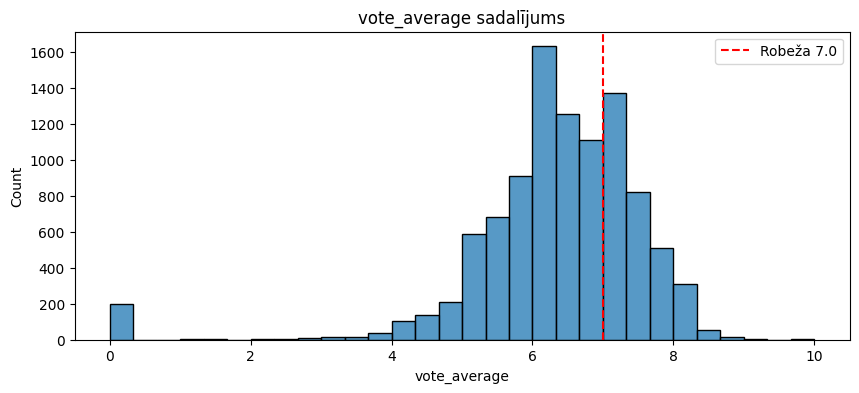

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cik filmas ar vote_average = 0?
print("Filmas ar vote_average = 0:", (df_movies['vote_average'] == 0).sum())
print("Filmas ar vote_count = 0:", (df_movies['vote_count'] == 0).sum())

# Sadalījuma grafiks
plt.figure(figsize=(10, 4))
sns.histplot(df_movies['vote_average'], bins=30)
plt.axvline(x=7.0, color='red', linestyle='--', label='Robeža 7.0')
plt.title('vote_average sadalījums')
plt.legend()
plt.show()

No datiem jāizņem 196 filmas, kuras nav novērtētas

In [5]:
# Izmet filmas bez balsīm
df_movies = df_movies[df_movies['vote_count'] > 0]
print("Dataseta izmērs pēc tīrīšanas:", df_movies.shape)

# Pārbaudi, kā izskatās vote_average sadalījums tagad
print("\nvote_average statistika pēc tīrīšanas:")
print(df_movies['vote_average'].describe())

# Cik filmas būs katrā klasē ar robežu 7.0?
augsti = (df_movies['vote_average'] > 7.0).sum()
zemi = (df_movies['vote_average'] <= 7.0).sum()
print(f"\nAugsti vērtētas (>7.0): {augsti} ({augsti/len(df_movies)*100:.1f}%)")
print(f"Zemi vērtētas (<=7.0): {zemi} ({zemi/len(df_movies)*100:.1f}%)")

Dataseta izmērs pēc tīrīšanas: (9804, 7)

vote_average statistika pēc tīrīšanas:
count    9804.000000
mean        6.456477
std         0.931416
min         1.000000
25%         5.900000
50%         6.500000
75%         7.100000
max        10.000000
Name: vote_average, dtype: float64

Augsti vērtētas (>7.0): 2748 (28.0%)
Zemi vērtētas (<=7.0): 7056 (72.0%)


In [6]:
# Izveido target kolonnu
df_movies['high_rating'] = (df_movies['vote_average'] > 7.0).astype(int)

# Pārbaudi original_lang - cik unikālas vērtības?
print("Unikālas valodas:", df_movies['original_lang'].nunique())
print("\nTop 10 valodas:")
print(df_movies['original_lang'].value_counts().head(10))

# Pārbaudi rel_date
print("\nrel_date piemēri:")
print(df_movies['rel_date'].head())
print("Missing rel_date:", df_movies['rel_date'].isnull().sum())

Unikālas valodas: 47

Top 10 valodas:
original_lang
en    8278
fr     411
ja     226
it     169
es     120
de     112
ko      71
cn      69
zh      56
ru      38
Name: count, dtype: int64

rel_date piemēri:
0    2014-10-22
1    2019-09-17
2    2020-01-15
3    2019-07-12
4    2018-06-06
Name: rel_date, dtype: object
Missing rel_date: 0


## Datu izpētes secinājumi

**Trūkstošās vērtības:**
`overview` kolonnai ir 21 trūkstoša vērtība (0.2%) — tā kā šo
kolonnu klasifikācijai neizmantošu (tā ir gara teksta kolonna), to izņemsim. `rel_date` kolonnai pēc nenovērtēto filmu izņemšanas trūkstošo
vērtību nav. 196 filmas ar `vote_count = 0` un `vote_average = 0` tika
izņemtas, jo tām nav reāla vērtējuma — pēc tīrīšanas paliek 9804 rindas.

**Kategoriskās kolonnas:**
`original_lang` ir kategoriska kolonna ar 47 unikālām vērtībām.
Tā kā angļu valoda dominē (8278 no 9804 filmām jeb ~84%), kolonnu
grupēšu: `en` paliek kā atsevišķa kategorija, pārējās apvienošu
grupā `other`. Tad lietošu One-Hot Encoding (2 kolonnas).
`rel_date` ir datuma kolonna — to sadalīšu pa gadiem (`year`),
kas dos noderīgu skaitlisku pazīmi.
`overview` un `title` kolonnas izņemšu, jo tekstu neapstrādāšu.

**Klašu līdzsvars un izlēcēji:**
Target kolonnā `high_rating` ir neliels disbalanss: 72% zemi vērtētas
filmas un 28% augsti vērtētas. Tas nav kritisks, tāpēc izlīdzināšana (SMOTE = Synthetic Minority Oversampling Technique) nebūs nepieciešama, taču F1 Score ir pareizā metrika šādā situācijā.
`popularity` kolonnā ir redzami izlēcēji — maksimums ir 818,
bet 75% filmu ir zem 15.

## Priekšapstrādes stratēģija

`overview` un `title` kolonnas izņemšu, jo tās ir garš teksts,
kas modelim nebūs nepieciešams.

`rel_date` kolonnu pārveidošu par `year` — skaitlisku pazīmi,
kas var palīdzēt modelim saprast, vai jaunākas filmas tiek vērtētas
citādi nekā vecākas.

`original_lang` kolonnu vienkāršošu: `en` = 0, viss pārējais = 1,
jo 84% filmu ir angļu valodā — 47 kategorijas ar One-Hot Encoding
radītu pārāk daudz kolonnu.

Target kolonna `high_rating` ir sabalansēta pietiekami
(72%/28%), tāpēc disbalansa izlīdzināšana (SMOTE) nebūs vajadzīga.

In [7]:
# Sagatavo datus
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Izveido year kolonnu
df_movies['year'] = pd.to_datetime(df_movies['rel_date']).dt.year

# Vienkāršo original_lang
df_movies['lang_en'] = (df_movies['original_lang'] == 'en').astype(int)

# Definē X un y
X = df_movies[['popularity', 'vote_count', 'year', 'lang_en']]
y = df_movies['high_rating']

print("X izmērs:", X.shape)
print("y sadalījums:\n", y.value_counts())

X izmērs: (9804, 4)
y sadalījums:
 high_rating
0    7056
1    2748
Name: count, dtype: int64


In [8]:
# Izveido Pipeline
pipe_base = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(random_state=42)
)

# Cross-validation
scores = cross_val_score(pipe_base, X, y, cv=5, scoring='f1')

print(f"CV F1 rezultāti: {scores}")
print(f"Vidējais CV F1: {scores.mean():.4f}")
print(f"Std dev: {scores.std():.4f}")

CV F1 rezultāti: [0.5516129  0.32432432 0.41018767 0.45454545 0.45508982]
Vidējais CV F1: 0.4392
Std dev: 0.0737


## Bāzes modeļa interpretācija

Bāzes modelis (Logistic Regression ar Pipeline) uzrādīja CV F1 = 0.4392 ± 0.0737.
Šis rezultāts ir zems, kas ir sagaidāms — Logistic Regression ir vienkāršs
lineārs modelis, kas var neuzķert sarežģītākas sakarības starp pazīmēm.
Liela standartnovirze (std dev) (0.0737) norāda, ka modelis nav stabils — rezultāti
būtiski atšķiras atkarībā no tā, kuri dati nonāk testēšanas daļā.
Tādēļ tālāk mēģināšu uzlabot rezultātu, izmantojot sarežģītākus modeļus
(Random Forest, Gradient Boosting) un GridSearchCV hiperparametru
optimizāciju.

In [9]:
# Izmet nevajadzīgās kolonnas
df_clean = df_movies.drop(columns=['title', 'overview', 'original_lang',
                                    'rel_date', 'vote_average'])

# Pārbaudi rezultātu
print("Kolonnas:", df_clean.columns.tolist())
print("Missing values:\n", df_clean.isnull().sum())
print("Izmērs:", df_clean.shape)

Kolonnas: ['popularity', 'vote_count', 'high_rating', 'year', 'lang_en']
Missing values:
 popularity     0
vote_count     0
high_rating    0
year           0
lang_en        0
dtype: int64
Izmērs: (9804, 5)


In [10]:
# Jaunā pazīme 1: vai filma ir populāra? (popularity virs vidējā)
df_clean['is_popular'] = (df_movies['popularity'] > df_movies['popularity'].mean()).astype(int)

# Jaunā pazīme 2: balsu intensitāte (cik daudz balsu uz vienu popularitātes punktu)
df_clean['votes_per_popularity'] = df_movies['vote_count'] / df_movies['popularity']

# Pārbaudi
print("Jaunās kolonnas:")
print(df_clean[['is_popular', 'votes_per_popularity']].describe())

# Korelācija ar target kolonnu
print("\nKorelācija ar high_rating:")
print(df_clean.corr()['high_rating'].sort_values(ascending=False))

Jaunās kolonnas:
        is_popular  votes_per_popularity
count  9804.000000           9804.000000
mean      0.263260             57.168849
std       0.440425             76.467280
min       0.000000              0.009832
25%       0.000000             12.824234
50%       0.000000             26.630683
75%       1.000000             68.136076
max       1.000000            953.791045

Korelācija ar high_rating:
high_rating             1.000000
vote_count              0.209098
votes_per_popularity    0.175351
is_popular              0.101359
popularity              0.080983
lang_en                -0.226313
year                   -0.267989
Name: high_rating, dtype: float64


## Feature Engineering secinājumi

Izveidoju divas jaunas pazīmes, balstoties uz EDA rezultātiem.

Pirmā pazīme `is_popular` norāda, vai filmas popularitāte pārsniedz
vidējo (14.8) — tā ir binārā pazīme, kas palīdz modelim atšķirt
īpaši populāras filmas.

Otrā pazīme `votes_per_popularity` aprēķina
balsu skaitu uz vienu popularitātes punktu — tā raksturo, cik
"nopelnīta" ir filmas popularitāte salīdzinājumā ar faktisko
skatītāju iesaisti.
Korelācijas analīze parādīja, ka abas jaunās pazīmes korelē ar
target kolonnu `high_rating` (0.175 un 0.101), kas liecina, ka
tās var uzlabot modeļa veiktspēju.

Interesants atklājums — `year` kolonna uzrāda negatīvu korelāciju
(-0.268), kas nozīmē, ka vecākas filmas mēdz būt augstāk vērtētas
nekā jaunākas. Interesanti arī, ka filmas angļu valodā retāk ir augstu vērtētas (negatīva korelācija -0.226)


In [11]:
# Sagatavo datus un salīdzina 3 modeļus
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Definē X un y ar jaunajām pazīmēm
X = df_clean.drop(columns=['high_rating'])
y = df_clean['high_rating']

# Definē modeļus
models = {
    'LogisticRegression': make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        LogisticRegression(random_state=42)
    ),
    'RandomForest': make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestClassifier(random_state=42)
    ),
    'GradientBoosting': make_pipeline(
        SimpleImputer(strategy='median'),
        GradientBoostingClassifier(random_state=42)
    )
}

# Salīdzini modeļus
print("Modeļu salīdzinājums:")
print("-" * 50)
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='f1')
    print(f"{name}:")
    print(f"  CV F1: {scores.mean():.4f} ± {scores.std():.4f}")
print("-" * 50)

Modeļu salīdzinājums:
--------------------------------------------------
LogisticRegression:
  CV F1: 0.4106 ± 0.0872
RandomForest:
  CV F1: 0.3284 ± 0.1193
GradientBoosting:
  CV F1: 0.3130 ± 0.1425
--------------------------------------------------


Rezultāti ir zemi un pat sliktāki nekā bāzes modelis. Parasti Random Forest un GradientBoosting strādā labāk. Visticamāk problēma ir klašu disbalansā (72%/28%). Pamēģināsim to labot.

In [12]:
# Pievieno class_weight='balanced' - modelis pievērš vairāk uzmanības
# mazākajai klasei (augsti vērtētās filmas)
models_balanced = {
    'LogisticRegression': make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        LogisticRegression(random_state=42, class_weight='balanced')
    ),
    'RandomForest': make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestClassifier(random_state=42, class_weight='balanced')
    ),
    'GradientBoosting': make_pipeline(
        SimpleImputer(strategy='median'),
        GradientBoostingClassifier(random_state=42)
    )
}

print("Modeļu salīdzinājums (ar balanced):")
print("-" * 50)
for name, pipe in models_balanced.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='f1')
    print(f"{name}:")
    print(f"  CV F1: {scores.mean():.4f} ± {scores.std():.4f}")
print("-" * 50)

Modeļu salīdzinājums (ar balanced):
--------------------------------------------------
LogisticRegression:
  CV F1: 0.5152 ± 0.0689
RandomForest:
  CV F1: 0.2836 ± 0.1728
GradientBoosting:
  CV F1: 0.3130 ± 0.1425
--------------------------------------------------


Interesanti — class_weight='balanced' palīdzēja LogisticRegression, bet Random Forest kļuva vēl sliktāks. Tas norāda uz dziļāku problēmu. Pamēģināšu pārbaudīt, vai problēma ir manā definētajā target kolonnas rādījuma (augsts/zems vērtējums, robeža - 7)

In [13]:
# Pārbaudi, vai vote_average = 7.0 rada problēmu
print("vote_average sadalījums ap 7.0:")
print(df_movies['vote_average'].value_counts().sort_index().loc[6.5:7.5])

# Pamēģini citu robežu - varbūt 7.0 nav labākā robeža?
for threshold in [6.0, 6.5, 7.0, 7.5]:
    high = (df_movies[df_movies['vote_count'] > 0]['vote_average'] > threshold).sum()
    total = len(df_movies[df_movies['vote_count'] > 0])
    print(f"Robeža {threshold}: {high} augsti ({high/total*100:.1f}%) / {total-high} zemi ({(total-high)/total*100:.1f}%)")

vote_average sadalījums ap 7.0:
vote_average
6.5    403
6.6    416
6.7    381
6.8    381
6.9    350
7.0    344
7.1    358
7.2    340
7.3    327
7.4    315
7.5    284
Name: count, dtype: int64
Robeža 6.0: 6701 augsti (68.3%) / 3103 zemi (31.7%)
Robeža 6.5: 4620 augsti (47.1%) / 5184 zemi (52.9%)
Robeža 7.0: 2748 augsti (28.0%) / 7056 zemi (72.0%)
Robeža 7.5: 1124 augsti (11.5%) / 8680 zemi (88.5%)


Labāks sadalījums ir ar robežu 6.5

In [14]:
# Izveido jaunu target kolonnu ar robežu 6.5
df_clean['high_rating'] = (df_movies[df_movies['vote_count'] > 0]['vote_average'] > 6.5).astype(int)

X = df_clean.drop(columns=['high_rating'])
y = df_clean['high_rating']

print("Jaunais y sadalījums:")
print(y.value_counts())
print(f"\n{y.value_counts()[1]/len(y)*100:.1f}% augsti / {y.value_counts()[0]/len(y)*100:.1f}% zemi")

# Salīdzini modeļus ar jauno robežu
print("\nModeļu salīdzinājums (robeža 6.5):")
print("-" * 50)
for name, pipe in models_balanced.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='f1')
    print(f"{name}:")
    print(f"  CV F1: {scores.mean():.4f} ± {scores.std():.4f}")
print("-" * 50)

Jaunais y sadalījums:
high_rating
0    5184
1    4620
Name: count, dtype: int64

47.1% augsti / 52.9% zemi

Modeļu salīdzinājums (robeža 6.5):
--------------------------------------------------
LogisticRegression:
  CV F1: 0.5958 ± 0.0423
RandomForest:
  CV F1: 0.5059 ± 0.0949
GradientBoosting:
  CV F1: 0.4779 ± 0.1305
--------------------------------------------------


Robeža 6.5 ievērojami uzlaboja visus modeļus. Bet LogisticRegression joprojām uzvar. Pamēģināšu bez class_weight='balanced', jo tagad klases ir gandrīz līdzsvarotas

In [15]:
models_new = {
    'LogisticRegression': make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        LogisticRegression(random_state=42)
    ),
    'RandomForest': make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestClassifier(random_state=42)
    ),
    'GradientBoosting': make_pipeline(
        SimpleImputer(strategy='median'),
        GradientBoostingClassifier(random_state=42)
    )
}

print("Modeļu salīdzinājums (robeža 6.5, bez balanced):")
print("-" * 50)
for name, pipe in models_new.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='f1')
    print(f"{name}:")
    print(f"  CV F1: {scores.mean():.4f} ± {scores.std():.4f}")
print("-" * 50)

Modeļu salīdzinājums (robeža 6.5, bez balanced):
--------------------------------------------------
LogisticRegression:
  CV F1: 0.5854 ± 0.0459
RandomForest:
  CV F1: 0.5161 ± 0.0875
GradientBoosting:
  CV F1: 0.4779 ± 0.1305
--------------------------------------------------


Tālāk GridSearch ar šādiem izvēlētajiem hiperparametriem:

C = cik ļoti modelis uzticas datiem

Mazs C (0.01) → modelis ir "piesardzīgs", ignorē izlēcējus → var būt par vienkāršu
Liels C (100) → modelis ļoti uzticas datiem → var pārmācīties (overfitting)
C=1 → noklusējuma līdzsvars


max_iter = cik reizes modelis drīkst "mēģināt uzlabot" sevi

Ja pārāk mazs → modelis nepaspēj atrast labāko atbildi (saņem brīdinājumu)
Ja liels → modelis paspēj "konverģēt" → atrast stabilu atbildi
Parasti 100 pietiek, bet sarežģītiem datiem vajag vairāk


solver = matemātiskais algoritms, ko modelis izmanto iekšēji

lbfgs → laba izvēle lieliem datasetiem
liblinear → laba izvēle maziem datasetiem un ja ir daudz pazīmju

In [16]:
#Turpinām ar GridSearchCV
from sklearn.model_selection import GridSearchCV

# Definē parametru režģi LogisticRegression
param_grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__max_iter': [100, 200, 500],
    'logisticregression__solver': ['lbfgs', 'liblinear']
}

# Izveido GridSearchCV
best_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(random_state=42, class_weight='balanced')
)

grid_search = GridSearchCV(
    best_pipe,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X, y)

print(f"Labākie parametri: {grid_search.best_params_}")
print(f"Labākais CV F1: {grid_search.best_score_:.4f}")

Labākie parametri: {'logisticregression__C': 0.01, 'logisticregression__max_iter': 100, 'logisticregression__solver': 'lbfgs'}
Labākais CV F1: 0.6042


## Modeļu salīdzinājums

| Modelis | CV F1 (vidējais) | CV F1 (std) | Piezīmes |
|---|---|---|---|
| Bāzes modelis (robeža 7.0) | 0.4392 | 0.0737 | Sākotnējais rezultāts |
| LogisticRegression (robeža 6.5) | 0.5958 | 0.0423 | Ar balanced |
| RandomForest (robeža 6.5) | 0.5059 | 0.0949 | Ar balanced |
| GradientBoosting (robeža 6.5) | 0.4779 | 0.1305 | - |
| GridSearchCV labākais | 0.6042 | - | C=0.01, lbfgs |

Labākais modelis ir LogisticRegression ar GridSearchCV optimizāciju
(CV F1 = 0.6042), kas pārspēj bāzes modeli par +0.165 jeb 37.6%.
Lielākais uzlabojums nāca nevis no sarežģītāka modeļa, bet gan no
target kolonnas robežas maiņas no 7.0 uz 6.5, kas radīja gandrīz
līdzsvarotu klašu sadalījumu (47%/53%). GridSearchCV atrada, ka
mazs C=0.01 strādā vislabāk, kas nozīmē, ka modelim ir labāk būt
"piesardzīgam" un nepārmācīties uz trenēšanas datiem.

Tālāk apmācu labāko modeli (LogisticRegression) un iegūstu koeficientus, kas norāda, cik ļoti katra pazīme ietekmē modeļa lēmumu.

Pozitīvs koeficients → jo lielāka šī pazīme, jo lielāka iespēja, ka filma ir augsti vērtēta (1)

Negatīvs koeficients → jo lielāka šī pazīme, jo lielāka iespēja, ka filma ir zemi vērtēta (0)

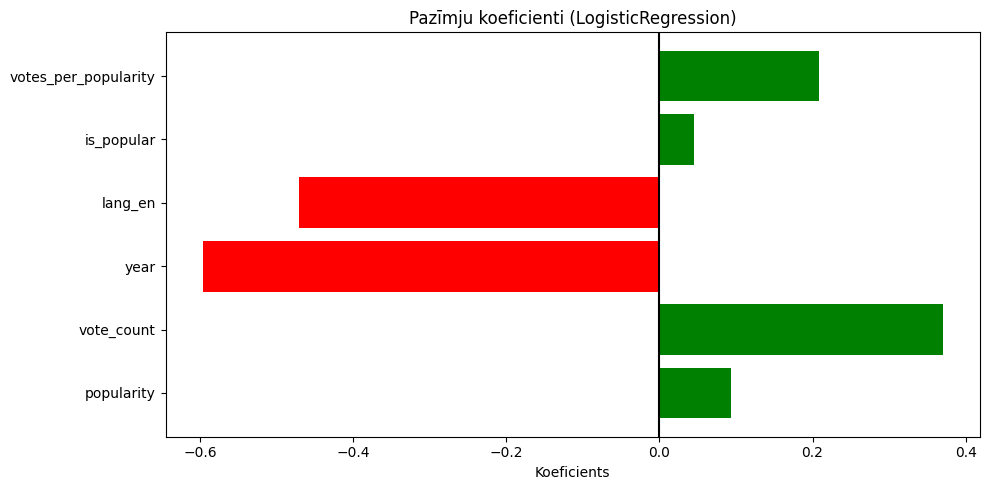

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Sadalī datos train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apmāci labāko modeli
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# Iegūsti koeficientus (LogisticRegression vietā Feature Importance ir koeficienti)
feature_names = X.columns.tolist()
coefficients = best_model.named_steps['logisticregression'].coef_[0]

# Vizualizē
plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coefficients]
plt.barh(feature_names, coefficients, color=colors)
plt.title('Pazīmju koeficienti (LogisticRegression)')
plt.xlabel('Koeficients')
plt.axvline(x=0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

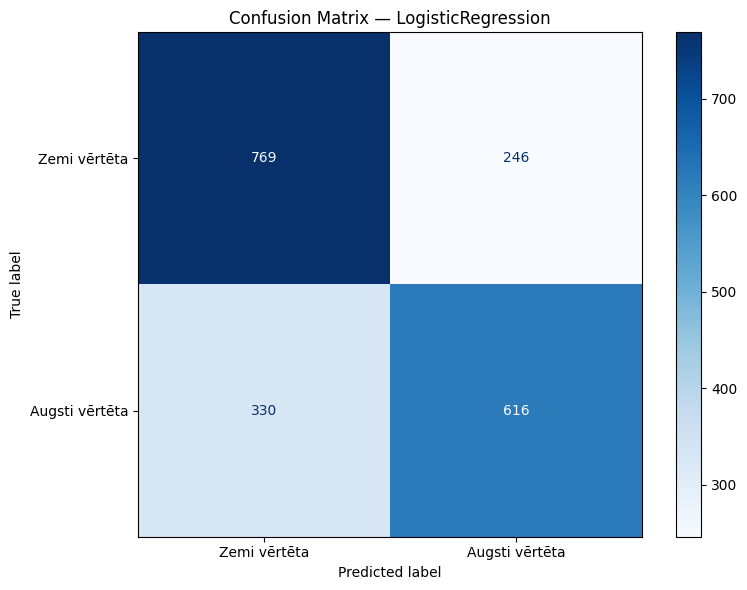


Classification Report:
                precision    recall  f1-score   support

  Zemi vērtēta       0.70      0.76      0.73      1015
Augsti vērtēta       0.71      0.65      0.68       946

      accuracy                           0.71      1961
     macro avg       0.71      0.70      0.70      1961
  weighted avg       0.71      0.71      0.71      1961



In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
              display_labels=['Zemi vērtēta', 'Augsti vērtēta'])
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix — LogisticRegression')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred,
      target_names=['Zemi vērtēta', 'Augsti vērtēta']))

## Secinājumi

**Ko modelis iemācījās?**
Svarīgākās pazīmes ir `year` (negatīvs koeficients -0.6) un `lang_en`
(negatīvs koeficients -0.5) — vecākas un ne-angļu valodas filmas mēdz
būt augstāk vērtētas. `vote_count` ir spēcīgākā pozitīvā pazīme (+0.4)
— filmas ar lielāku skatītāju iesaisti mēdz saņemt augstākus vērtējumus.
Tas ir loģiski, jo populāras un labi zināmas filmas parasti ir arī
augstāk novērtētas.

**Kur modelis kļūdās?**
Confusion Matrix parāda, ka modelis biežāk kļūdās ar augsti vērtētām
filmām — Recall = 0.65 nozīmē, ka 35% augsti vērtētu filmu modelis
nepareizi klasificē kā zemi vērtētas. Tas varētu būt tāpēc, ka
dažas filmas ir augsti vērtētas nišas iemeslu dēļ, ko mūsu pazīmes
neuzķer.

**Vai rezultāts ir praktiski noderīgs?**
Accuracy = 71% un F1 = 0.70 ir pieņemams rezultāts ņemot vērā, ka
mums ir tikai 6 pazīmes. Ja iesniegtu šo modeli pasūtītājam, teiktu,
ka modelis var kalpot kā sākotnējais filtrs filmu kvalitātes
novērtēšanai, taču nav pietiekami precīzs, lai pieņemtu galīgos
lēmumus bez cilvēka pārskata.

**Nākamie soļi:**
Ja būtu vēl 2 nedēļas, pievienotu žanru informāciju kā papildu
pazīmi, izmēģinātu dziļāku feature engineering (piemēram, filmas
vecumu dienās nevis gados), kā arī izmēģinātu ensemble metodes
apvienojot vairākus modeļus kopā, lai uzlabotu Recall augsti
vērtētām filmām.

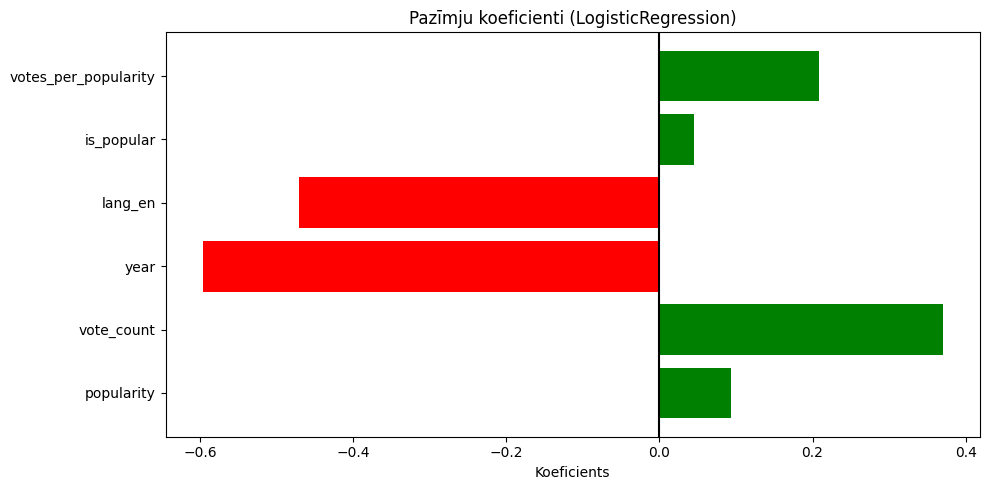

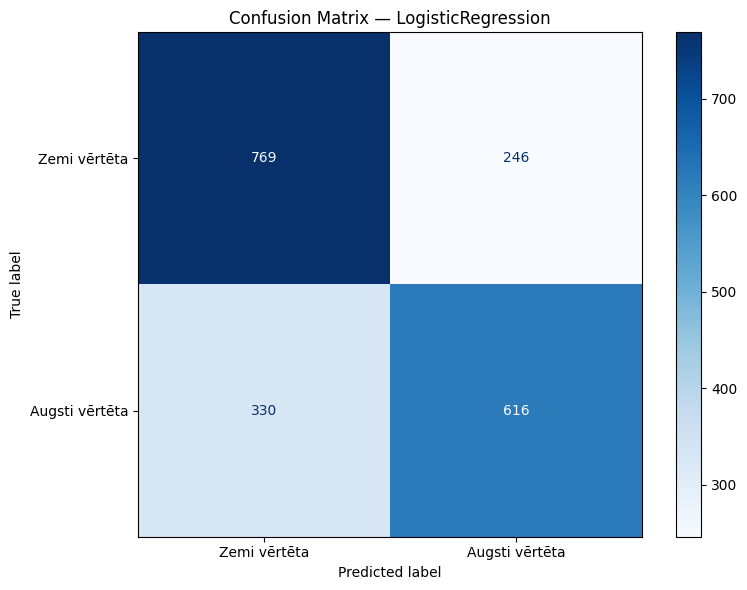

Grafiki saglabāti!


In [19]:
# Saglabā Feature Importance grafiku
plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coefficients]
plt.barh(feature_names, coefficients, color=colors)
plt.title('Pazīmju koeficienti (LogisticRegression)')
plt.xlabel('Koeficients')
plt.axvline(x=0, color='black', linestyle='-')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Saglabā Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
              display_labels=['Zemi vērtēta', 'Augsti vērtēta'])
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix — LogisticRegression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafiki saglabāti!")